## Import necessary library


In [60]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
import os
from matplotlib.colorbar import ColorbarBase

## Get File path and load the csv data


In [61]:
from util.data_path import cassava_price_avg_year_fix
from util.data_path import corn_price_avg_year_fix
from util.data_path import green_bean_price_avg_year_fix
from util.data_path import soybean_price_avg_year_fix

In [62]:
def process_csv(data_file):
    wide = pd.read_csv(data_file)
    long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
        ["year", "month"]
    )

    long["date"] = pd.to_datetime(
        (long["year"]).astype(str)
        + "-"
        + long["month"].astype(str).str.zfill(2)
        + "-01"
    )
    long = long.set_index("date").sort_index()
    return long


# Process each crop data
cassava_df = process_csv(cassava_price_avg_year_fix)
corn_df = process_csv(corn_price_avg_year_fix)
green_bean_df = process_csv(green_bean_price_avg_year_fix)
soybean_df = process_csv(soybean_price_avg_year_fix)

# Add crop name column to each dataframe
cassava_df["crop"] = "cassava"
corn_df["crop"] = "corn"
green_bean_df["crop"] = "green_bean"
soybean_df["crop"] = "soybean"

# Create a combined dataframe for all crops
all_crops_df = pd.concat([cassava_df, corn_df, green_bean_df, soybean_df])

## Price Trends Over Time Analysis

Let's create visualizations to analyze price trends for all crops over time and by month.


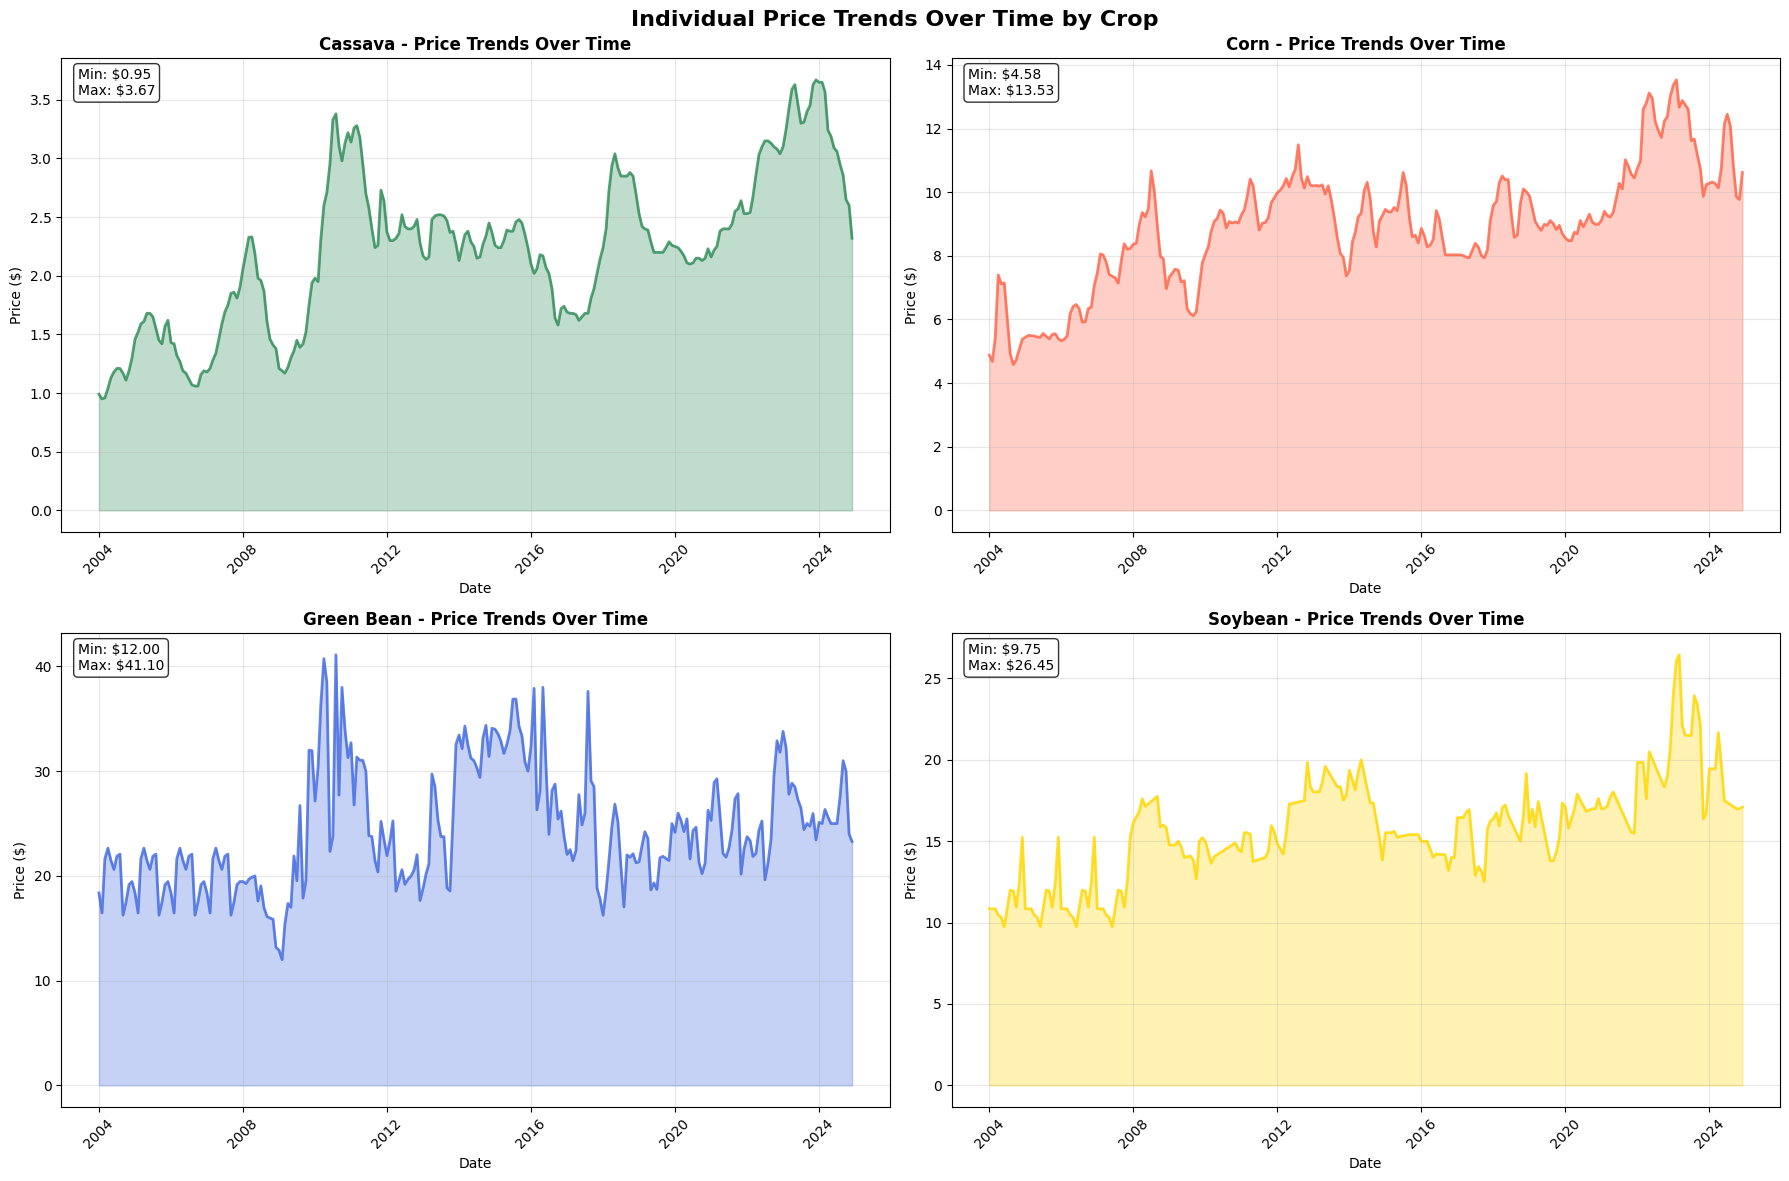

In [ ]:
# 1. Individual Price Trends Over Time for Each Crop (Separate Graphs)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(
    "Individual Price Trends Over Time by Crop", fontsize=16, fontweight="bold"
)

# Create color palette for crops
colors = [
    "#2E8B57",
    "#FF6347",
    "#4169E1",
    "#FFD700",
]  # SeaGreen, Tomato, RoyalBlue, Gold
crop_names = ["cassava", "corn", "green_bean", "soybean"]

for i, crop in enumerate(crop_names):
    row, col = divmod(i, 2)
    ax = axes[row, col]

    crop_data = all_crops_df[all_crops_df["crop"] == crop]
    ax.plot(
        crop_data.index,
        crop_data["price"],
        color=colors[i],
        linewidth=2,
        alpha=0.8,
    )

    # Fill area under the curve for better visual appeal
    ax.fill_between(crop_data.index, crop_data["price"], alpha=0.3, color=colors[i])

    ax.set_title(
        f"{crop.replace('_', ' ').title()} - Price Trends Over Time",
        fontweight="bold",
        fontsize=12,
    )
    ax.set_xlabel("Date", fontsize=10)
    ax.set_ylabel("Price ($)", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

    # Add min/max annotations
    min_price = crop_data["price"].min()
    max_price = crop_data["price"].max()
    ax.text(
        0.02,
        0.98,
        f"Min: ${min_price:.2f}\nMax: ${max_price:.2f}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

plt.tight_layout()
plt.show()

In [64]:
# Display basic statistics
print("Price Statistics Summary:")
print("=" * 50)
for crop in crop_names:
    crop_data = all_crops_df[all_crops_df["crop"] == crop]["price"]
    print(f"\n{crop.replace('_', ' ').title()}:")
    print(f"  Mean: ${crop_data.mean():.2f}")
    print(f"  Min:  ${crop_data.min():.2f}")
    print(f"  Max:  ${crop_data.max():.2f}")
    print(f"  Std:  ${crop_data.std():.2f}")

Price Statistics Summary:

Cassava:
  Mean: $2.22
  Min:  $0.95
  Max:  $3.67
  Std:  $0.66

Corn:
  Mean: $8.89
  Min:  $4.58
  Max:  $13.53
  Std:  $1.88

Green Bean:
  Mean: $24.34
  Min:  $12.00
  Max:  $41.10
  Std:  $5.70

Soybean:
  Mean: $15.70
  Min:  $9.75
  Max:  $26.45
  Std:  $3.06


In [65]:
# 2. Monthly Seasonal Trends Analysis - Data Preparation
# Extract month from date and calculate average prices by month
all_crops_df["month_num"] = all_crops_df.index.month
monthly_avg = all_crops_df.groupby(["crop", "month_num"])["price"].mean().reset_index()

months = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

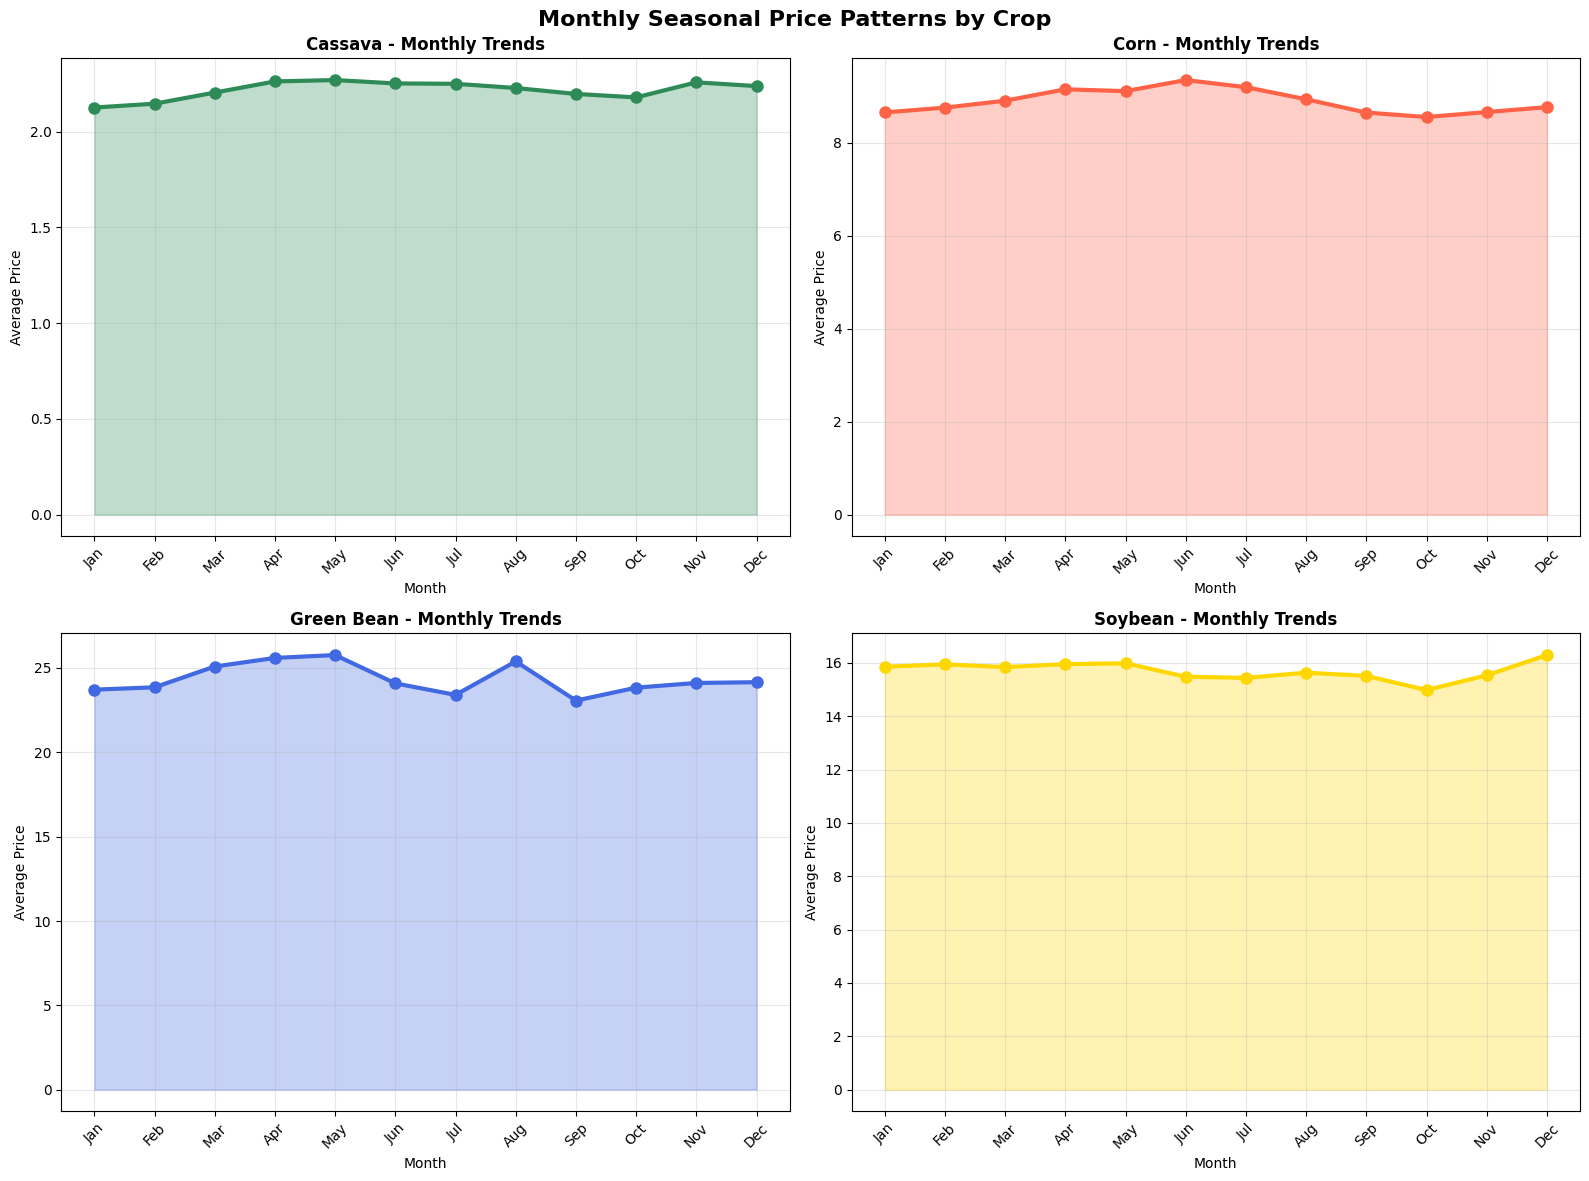

In [66]:
# 2a. Monthly Seasonal Trends - Individual Crop Subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Monthly Seasonal Price Patterns by Crop", fontsize=16, fontweight="bold")

for i, crop in enumerate(crop_names):
    row, col = divmod(i, 2)
    ax = axes[row, col]

    crop_monthly = monthly_avg[monthly_avg["crop"] == crop]

    ax.plot(
        crop_monthly["month_num"],
        crop_monthly["price"],
        marker="o",
        linewidth=3,
        markersize=8,
        color=colors[i],
    )
    ax.fill_between(
        crop_monthly["month_num"], crop_monthly["price"], alpha=0.3, color=colors[i]
    )

    ax.set_title(
        f"{crop.replace('_', ' ').title()} - Monthly Trends",
        fontweight="bold",
        fontsize=12,
    )
    ax.set_xlabel("Month")
    ax.set_ylabel("Average Price")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(months, rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

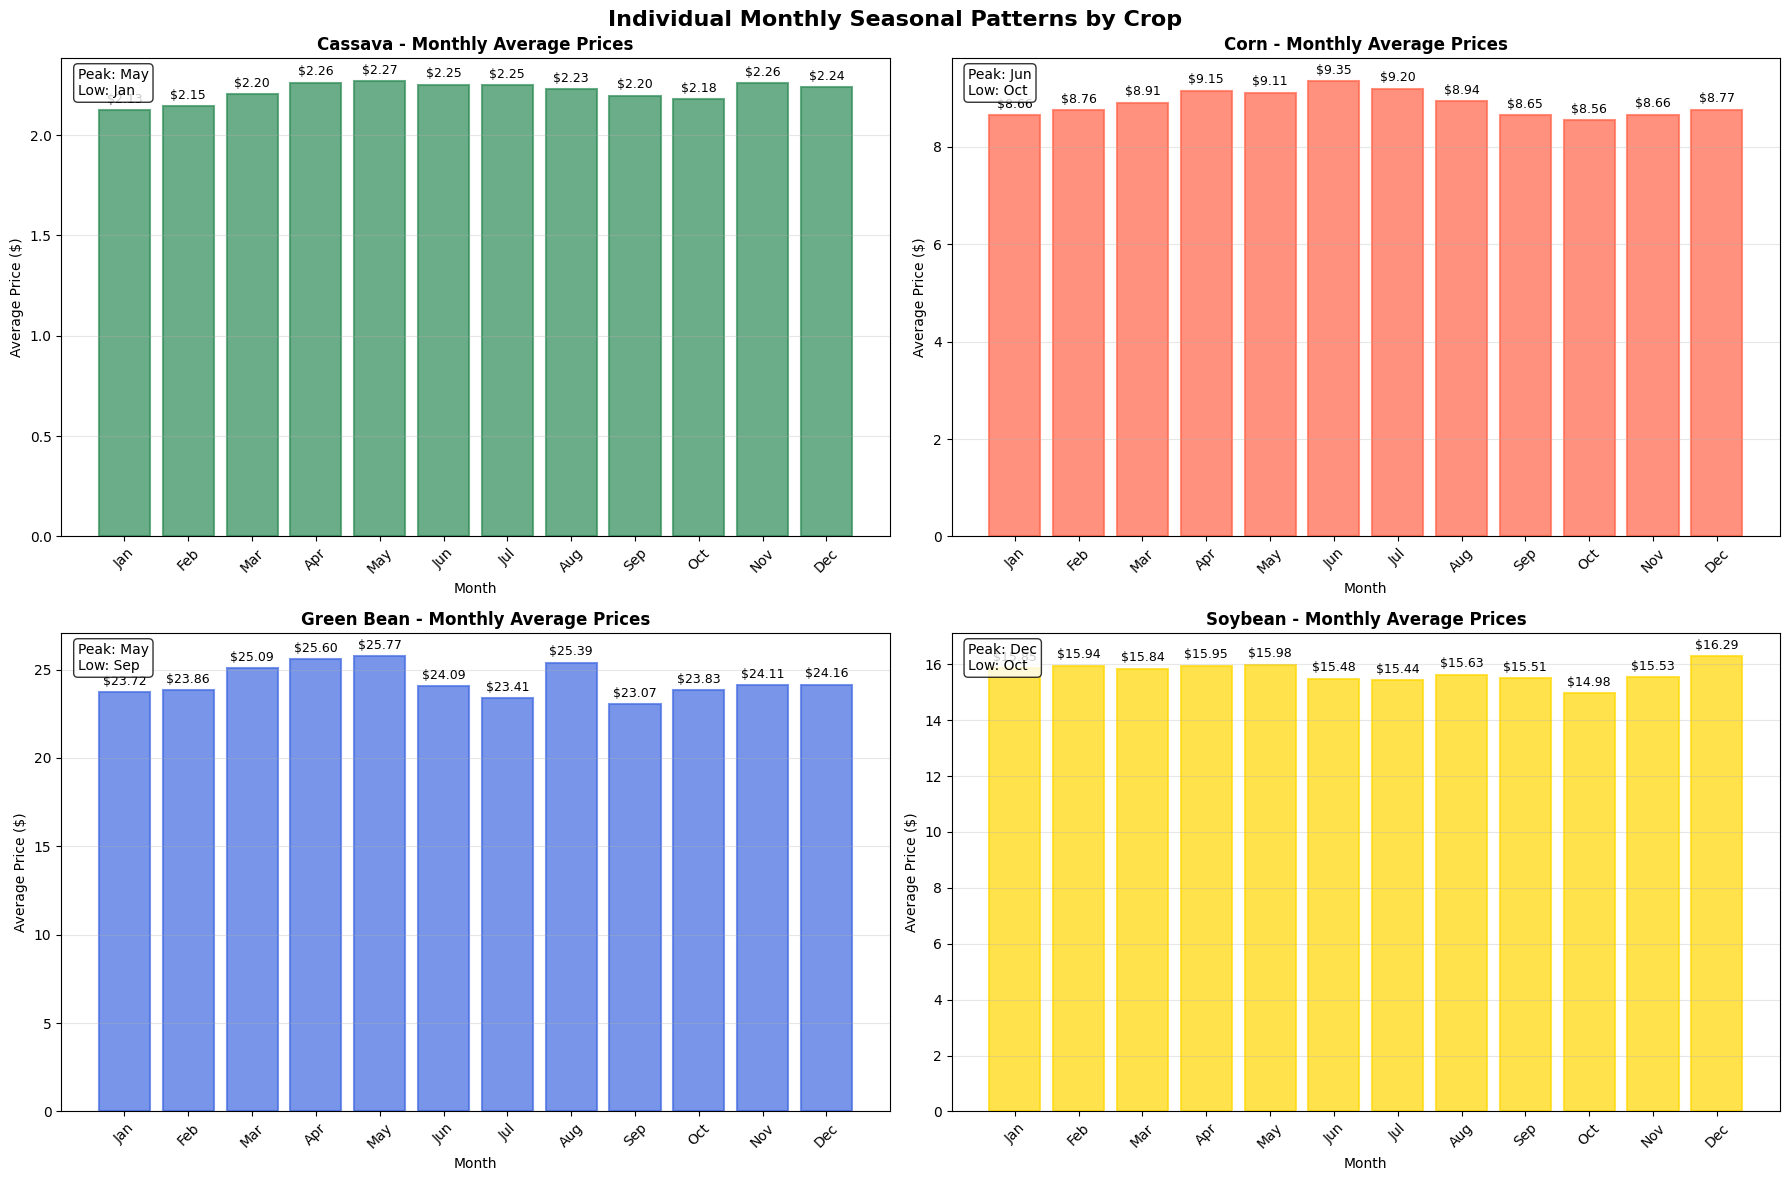

In [ ]:
# 2c. Individual Monthly Trends (Separate Graphs with Better Spacing)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(
    "Individual Monthly Seasonal Patterns by Crop", fontsize=16, fontweight="bold"
)

for i, crop in enumerate(crop_names):
    row, col = divmod(i, 2)
    ax = axes[row, col]

    crop_monthly = monthly_avg[monthly_avg["crop"] == crop]

    # Create bar chart for better monthly visualization
    bars = ax.bar(
        crop_monthly["month_num"],
        crop_monthly["price"],
        color=colors[i],
        alpha=0.7,
        edgecolor=colors[i],
        linewidth=1.5,
    )

    # Add value labels on top of bars
    for j, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height + height * 0.01,
            f"${height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_title(
        f"{crop.replace('_', ' ').title()} - Monthly Average Prices",
        fontweight="bold",
        fontsize=12,
    )
    ax.set_xlabel("Month", fontsize=10)
    ax.set_ylabel("Average Price ($)", fontsize=10)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(months, rotation=45)
    ax.grid(True, alpha=0.3, axis="y")

    # Highlight highest and lowest months
    highest_month = crop_monthly.loc[crop_monthly["price"].idxmax()]
    lowest_month = crop_monthly.loc[crop_monthly["price"].idxmin()]

    ax.text(
        0.02,
        0.98,
        f"Peak: {months[int(highest_month['month_num']) - 1]}\nLow: {months[int(lowest_month['month_num']) - 1]}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

plt.tight_layout()
plt.show()

In [68]:
# Display monthly statistics
print("\nMonthly Price Analysis:")
print("=" * 60)
for crop in crop_names:
    crop_monthly = monthly_avg[monthly_avg["crop"] == crop]
    highest_month = crop_monthly.loc[crop_monthly["price"].idxmax()]
    lowest_month = crop_monthly.loc[crop_monthly["price"].idxmin()]

    print(f"\n{crop.replace('_', ' ').title()}:")
    print(
        f"  Highest prices in: {months[int(highest_month['month_num']) - 1]} (${highest_month['price']:.2f})"
    )
    print(
        f"  Lowest prices in:  {months[int(lowest_month['month_num']) - 1]} (${lowest_month['price']:.2f})"
    )
    print(f"  Monthly variation: ${highest_month['price'] - lowest_month['price']:.2f}")


Monthly Price Analysis:

Cassava:
  Highest prices in: May ($2.27)
  Lowest prices in:  Jan ($2.13)
  Monthly variation: $0.14

Corn:
  Highest prices in: Jun ($9.35)
  Lowest prices in:  Oct ($8.56)
  Monthly variation: $0.80

Green Bean:
  Highest prices in: May ($25.77)
  Lowest prices in:  Sep ($23.07)
  Monthly variation: $2.70

Soybean:
  Highest prices in: Dec ($16.29)
  Lowest prices in:  Oct ($14.98)
  Monthly variation: $1.31


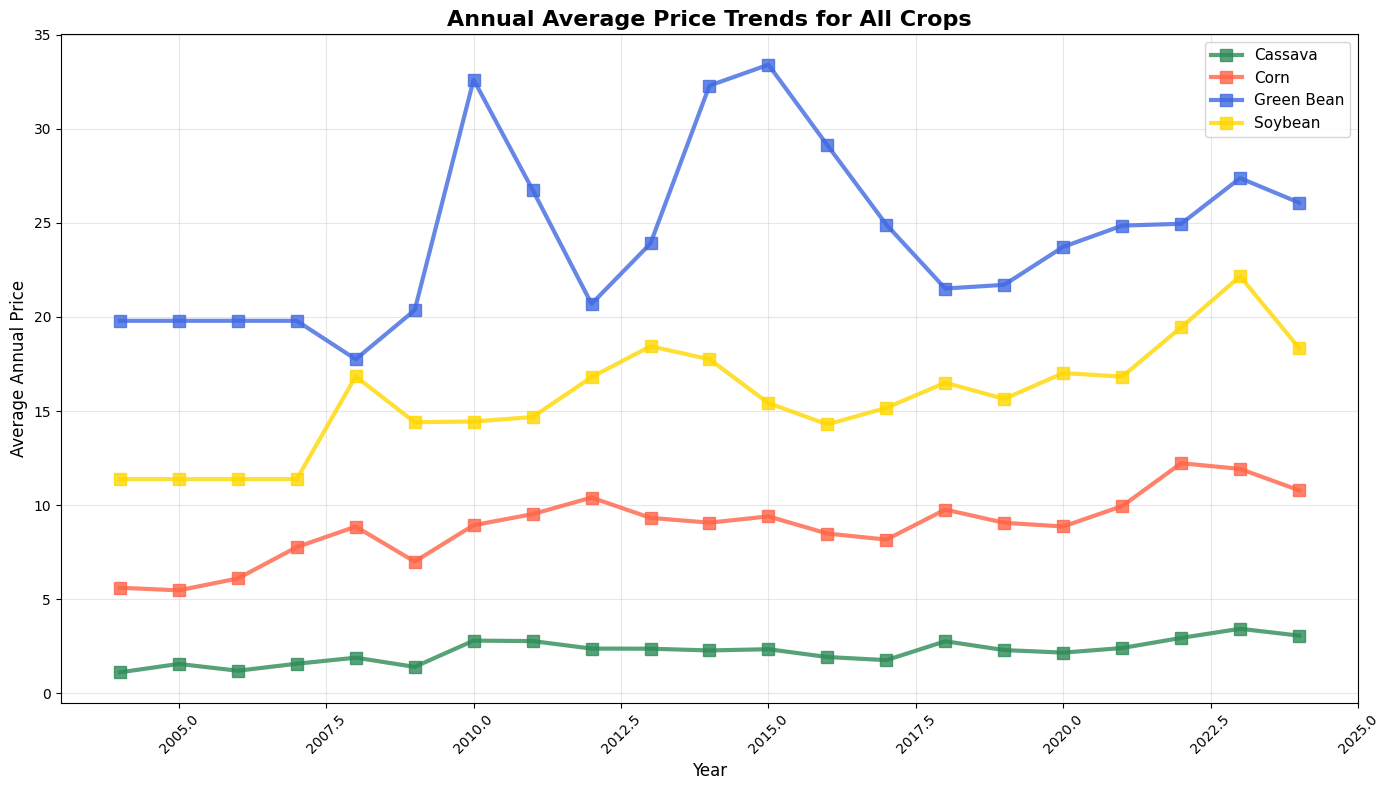


Year-over-Year Analysis:

Cassava:
  Average YoY growth: 8.59%
  Price range: $1.12 - $3.43
  Best year: 2023 ($3.43)
  Worst year: 2004 ($1.12)

Corn:
  Average YoY growth: 4.16%
  Price range: $5.48 - $12.23
  Best year: 2022 ($12.23)
  Worst year: 2005 ($5.48)

Green Bean:
  Average YoY growth: 2.87%
  Price range: $17.75 - $33.40
  Best year: 2015 ($33.40)
  Worst year: 2008 ($17.75)

Soybean:
  Average YoY growth: 3.25%
  Price range: $11.38 - $22.16
  Best year: 2023 ($22.16)
  Worst year: 2004 ($11.38)


In [69]:
# 3. Year-over-Year Trend Analysis - Data Preparation
yearly_avg = all_crops_df.groupby(["crop", "year"])["price"].mean().reset_index()

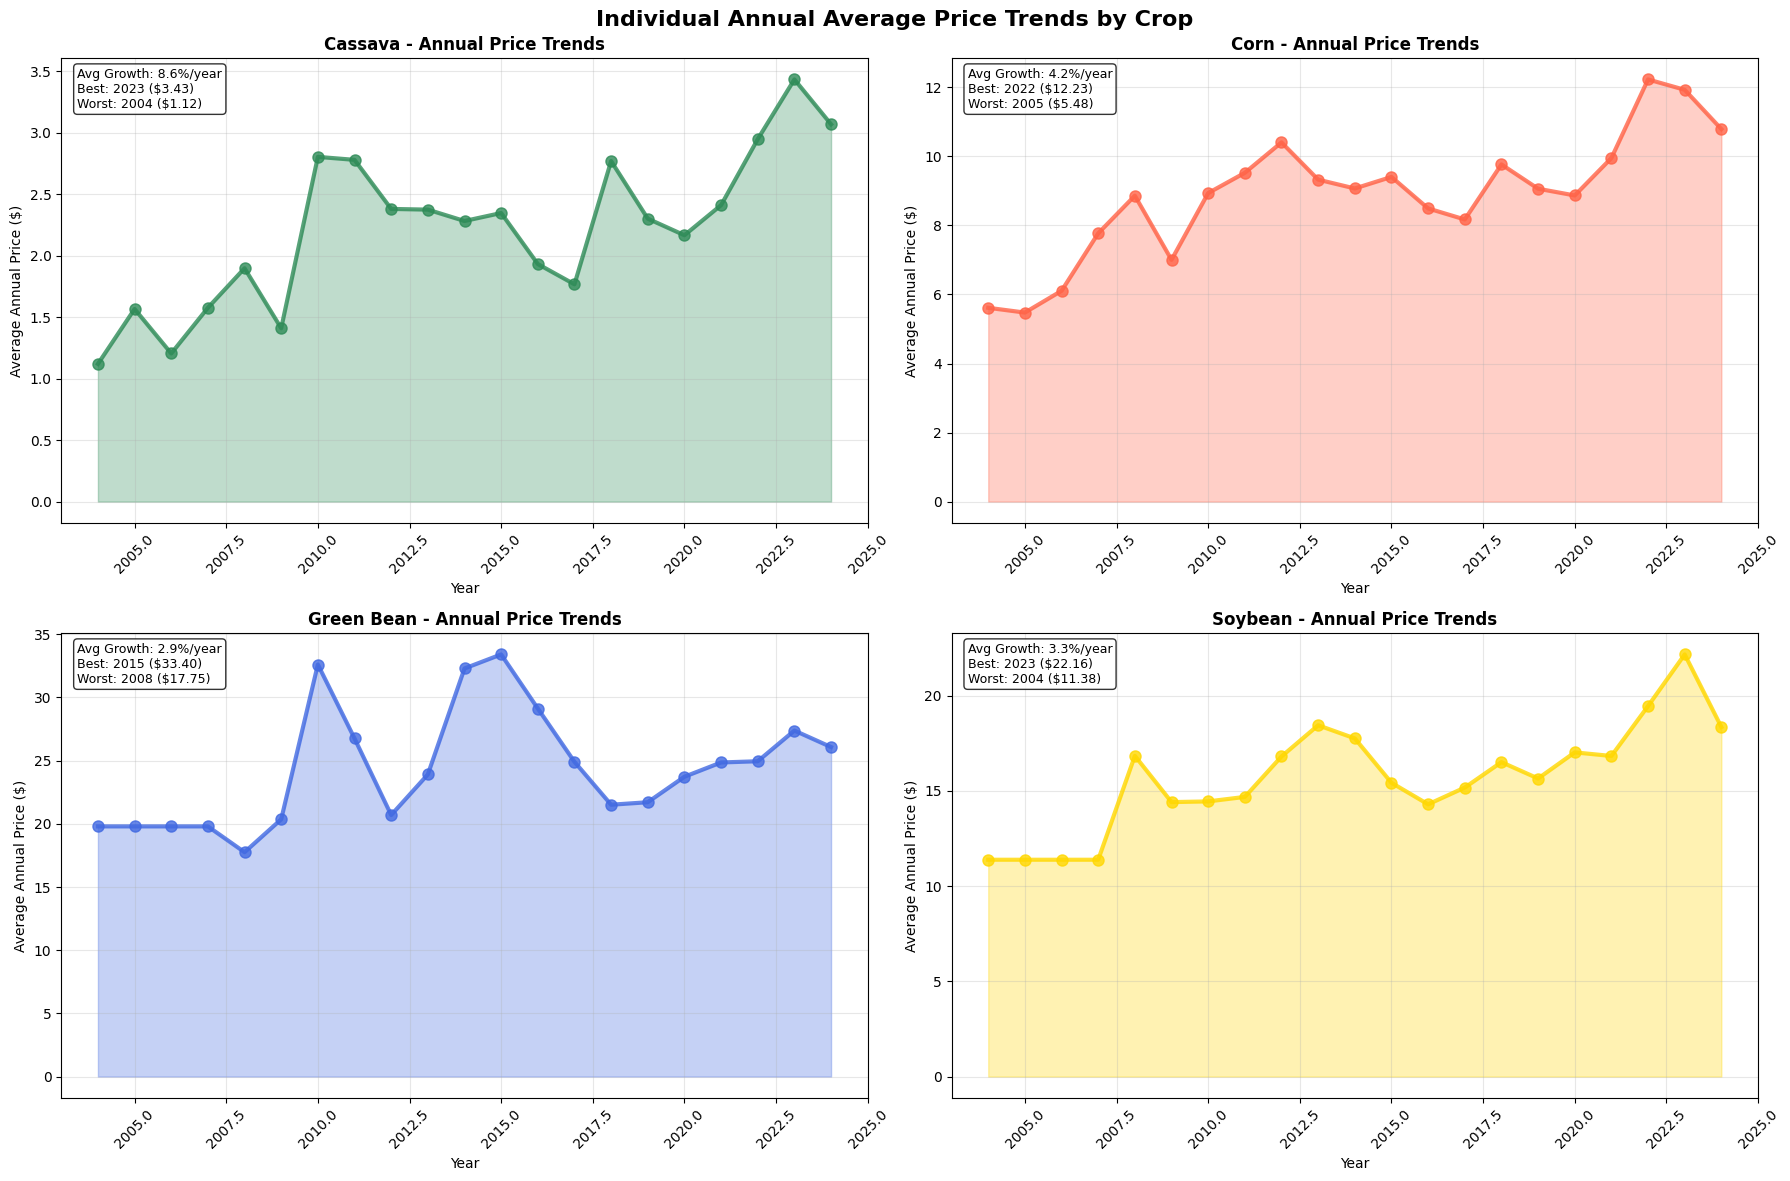

In [ ]:
# 3a. Individual Annual Trends (Separate Graphs)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(
    "Individual Annual Average Price Trends by Crop", fontsize=16, fontweight="bold"
)

for i, crop in enumerate(crop_names):
    row, col = divmod(i, 2)
    ax = axes[row, col]

    crop_yearly = yearly_avg[yearly_avg["crop"] == crop]

    # Create line plot with markers
    ax.plot(
        crop_yearly["year"],
        crop_yearly["price"],
        marker="o",
        linewidth=3,
        markersize=8,
        color=colors[i],
        alpha=0.8,
    )

    # Fill area under the curve
    ax.fill_between(
        crop_yearly["year"], crop_yearly["price"], alpha=0.3, color=colors[i]
    )

    ax.set_title(
        f"{crop.replace('_', ' ').title()} - Annual Price Trends",
        fontweight="bold",
        fontsize=12,
    )
    ax.set_xlabel("Year", fontsize=10)
    ax.set_ylabel("Average Annual Price ($)", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

    # Calculate and display growth statistics
    if len(crop_yearly) > 1:
        growth_rates = crop_yearly["price"].pct_change() * 100
        avg_growth = growth_rates.mean()

        # Find best and worst years
        best_year = crop_yearly.loc[crop_yearly["price"].idxmax()]
        worst_year = crop_yearly.loc[crop_yearly["price"].idxmin()]

        # Add statistics text box
        stats_text = f"Avg Growth: {avg_growth:.1f}%/year\nBest: {int(best_year['year'])} (${best_year['price']:.2f})\nWorst: {int(worst_year['year'])} (${worst_year['price']:.2f})"
        ax.text(
            0.02,
            0.98,
            stats_text,
            transform=ax.transAxes,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
            fontsize=9,
        )

plt.tight_layout()
plt.show()

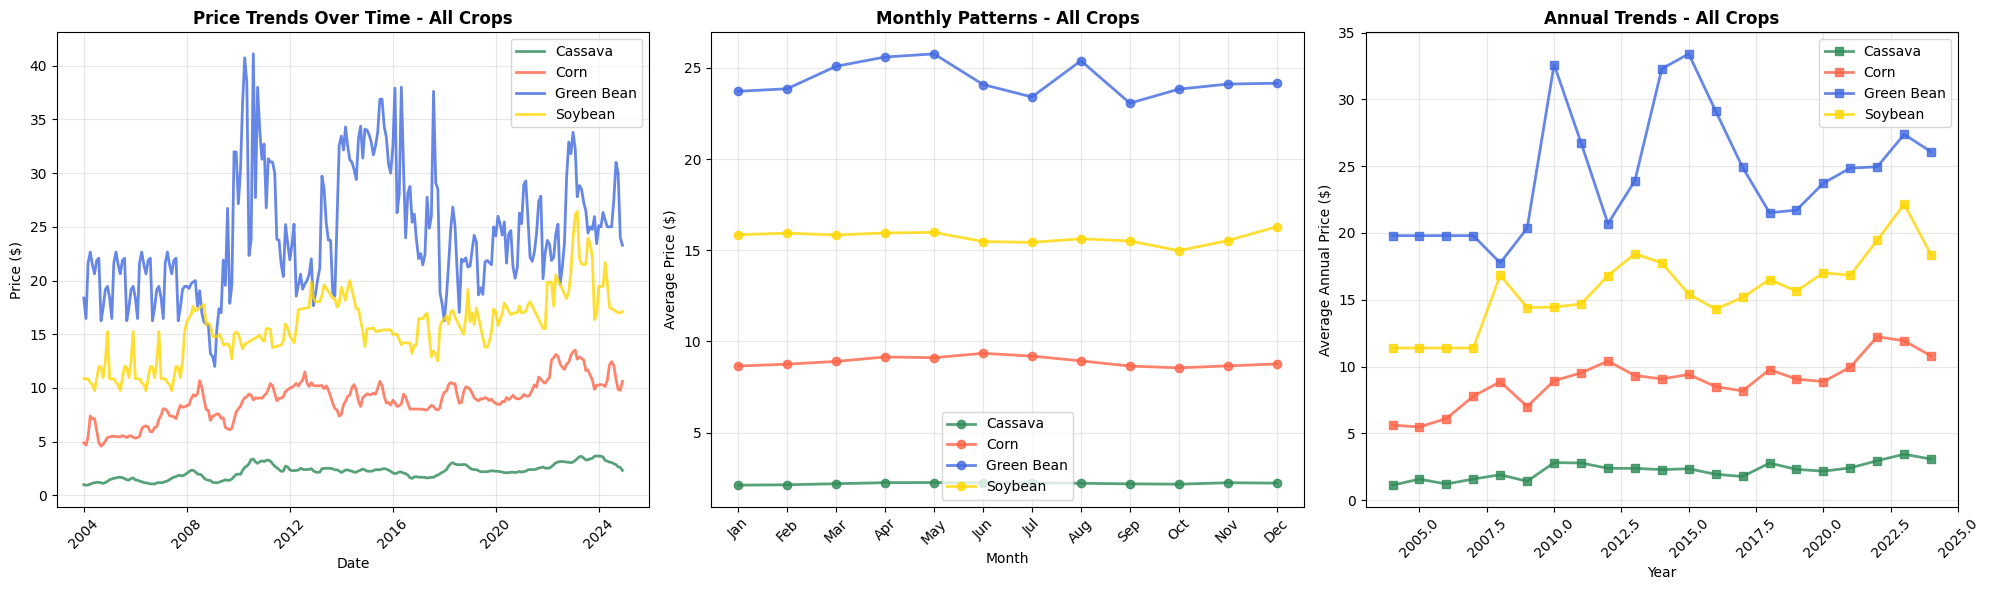

In [ ]:
# 4. Optional: Clean Comparison Views (All Crops Together but Well-Spaced)

# 4a. Price Trends Comparison with Better Scaling
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Time series comparison
ax1 = axes[0]
for i, crop in enumerate(crop_names):
    crop_data = all_crops_df[all_crops_df["crop"] == crop]
    ax1.plot(
        crop_data.index,
        crop_data["price"],
        label=crop.replace("_", " ").title(),
        color=colors[i],
        linewidth=2,
        alpha=0.8,
    )

ax1.set_title("Price Trends Over Time - All Crops", fontweight="bold")
ax1.set_xlabel("Date")
ax1.set_ylabel("Price ($)")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis="x", rotation=45)

# Monthly comparison
ax2 = axes[1]
for i, crop in enumerate(crop_names):
    crop_monthly = monthly_avg[monthly_avg["crop"] == crop]
    ax2.plot(
        crop_monthly["month_num"],
        crop_monthly["price"],
        marker="o",
        linewidth=2,
        markersize=6,
        label=crop.replace("_", " ").title(),
        color=colors[i],
        alpha=0.8,
    )

ax2.set_title("Monthly Patterns - All Crops", fontweight="bold")
ax2.set_xlabel("Month")
ax2.set_ylabel("Average Price ($)")
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels([m[:3] for m in months], rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Annual comparison
ax3 = axes[2]
for i, crop in enumerate(crop_names):
    crop_yearly = yearly_avg[yearly_avg["crop"] == crop]
    ax3.plot(
        crop_yearly["year"],
        crop_yearly["price"],
        marker="s",
        linewidth=2,
        markersize=6,
        label=crop.replace("_", " ").title(),
        color=colors[i],
        alpha=0.8,
    )

ax3.set_title("Annual Trends - All Crops", fontweight="bold")
ax3.set_xlabel("Year")
ax3.set_ylabel("Average Annual Price ($)")
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()